In [23]:
# ============================================================
# Development settings
# ============================================================
%load_ext autoreload
%autoreload 2

# ============================================================
# Standard library
# ============================================================
import sys
from pathlib import Path
import matplotlib.colors as mcolors
import colorcet as cc
# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# ============================================================
# Scientific / geospatial libraries
# ============================================================
import numpy as np
import pandas as pd
import geopandas as gpd
import h3

# ============================================================
# Project modules
# ============================================================
from src.hazard_framework import *
from src.plotting_function import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"

print("Project root:", PROJECT_ROOT)
print("Data:", DATA_DIR)
print("Figures:", FIGURE_DIR)

Project root: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification
Data: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data
Figures: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\figures


## 1. Application to an Alternative Polygon-Based Spatial Framework

The multi-hazard screening framework is designed to operate independently of a single predefined spatial aggregation system. Although the global analysis presented in the main workflow uses the H3 grid, the same calculations can be performed using externally defined polygon regions by setting `framework='polygon'`.

This example demonstrates the application of the framework using the **IPCC-WGI reference regions** as the aggregation units. The previously prepared global three-hazard dataset is first loaded and converted into the hazard scores used by the framework. Each coastal transect is then spatially assigned to the corresponding IPCC reference region. The Multi-Hazard Burden is subsequently recalculated by grouping the transects according to these polygon regions rather than H3 cells.

The underlying transect-level hazard information and burden formulation remain unchanged. Only the spatial units over which the observations are grouped and summarized are modified. This demonstrates that the framework can be transferred to predefined geographic divisions when comparison between established regions is more appropriate than analysis using a regular spatial grid.

In [ ]:
ipccc_shp =DATA_DIR / 'IPCC region/IPCC-WGI-reference-regions-v4.shp'
gdf = gpd.read_parquet(DATA_DIR / 'mapped_hazard.parquet')
gdf = hazard_scoring(gdf)
poly_gdf = assign_aggregation_framework(gdf,framework='polygon',polygon_file=ipccc_shp)
poly_burden = calculate_burden(poly_gdf,framework='polygon',polygon_file=ipccc_shp)

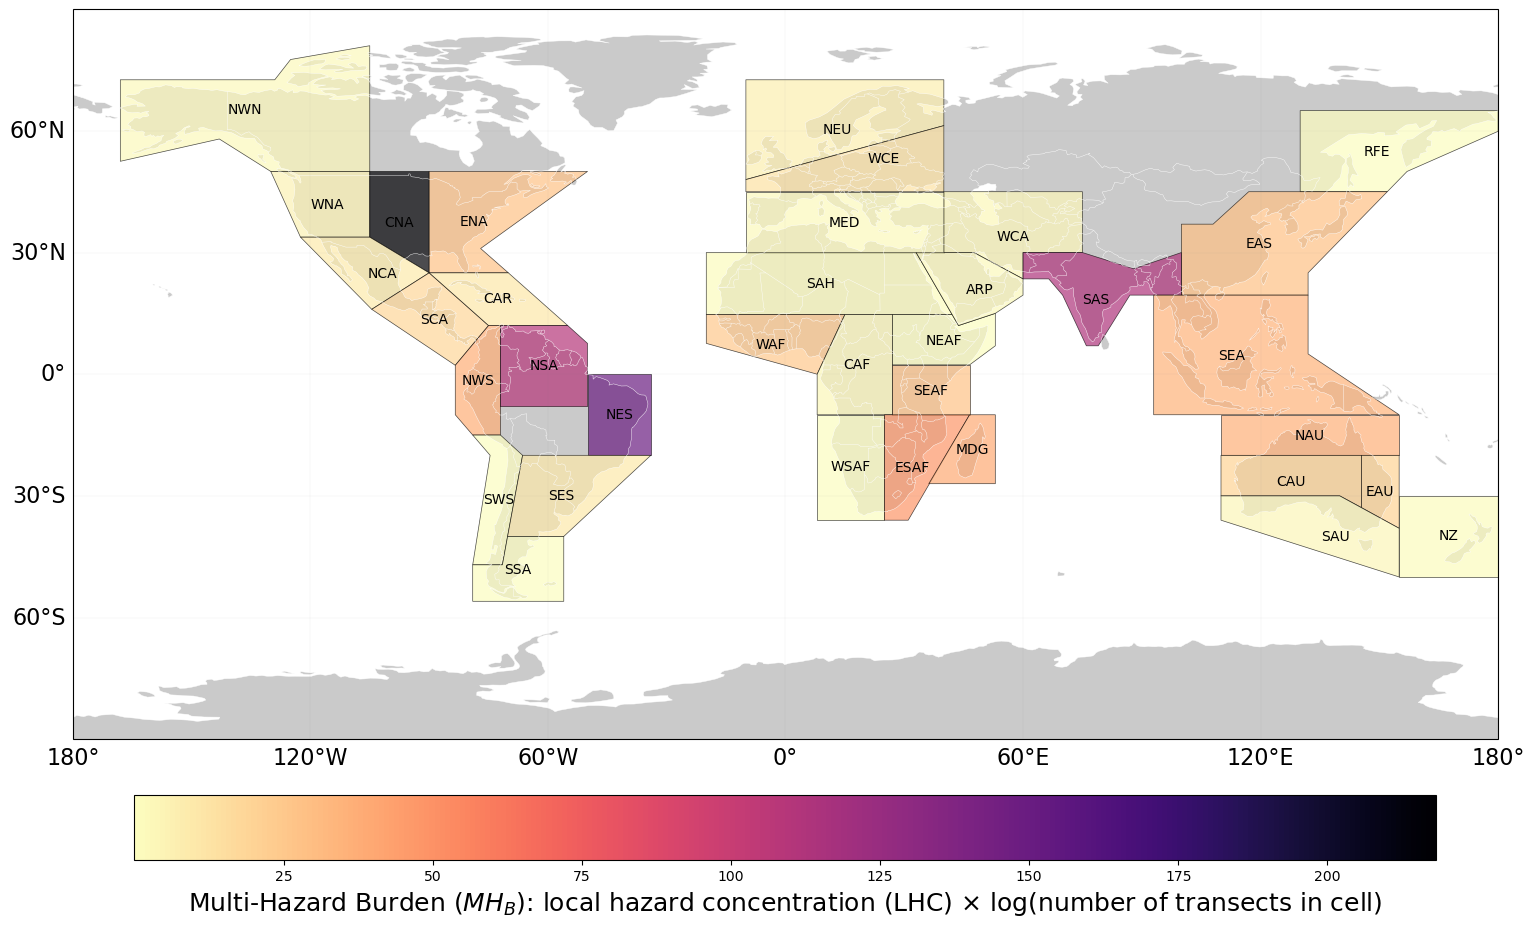

In [ ]:

fig, ax = initialize_map(figsize=(24,12))

key = 'MHB'

vmin = poly_burden[key].quantile(0.01)
vmax = poly_burden[key].quantile(0.99)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

poly_burden.plot(
    column=key,
    cmap=plt.cm.magma_r,
    ax=ax,
    legend=True,
    edgecolor="black",
    alpha=0.7,
    linewidth=0.5,
        legend_kwds={
        # "label": "Conditional flood amplification ratio",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.06
    }
)

cbar_ax = fig.axes[-1]
cbar_ax.set_xlabel(
    r"Multi-Hazard Burden ($MH_B$): local hazard concentration (LHC) × log(number of transects in cell)",
    fontsize=18
)

for x, y, label in zip(
    poly_burden.geometry.representative_point().x,
    poly_burden.geometry.representative_point().y,
    poly_burden["Acronym"]
):
    ax.text(x, y, label, ha="center", va="center")

plt.show()

## 2. Application at a Finer Spatial Scale

The framework can also be applied to a smaller geographic domain at a finer spatial resolution without changing the underlying hazard-screening methodology. This example demonstrates the approach for **Indonesia**, where the global transect dataset is first spatially filtered to retain only coastal transects associated with the selected country.

In [ ]:
# filter the GCTS with country name and increase the resolution of the H3 framework
gdf_filtered = gdf[gdf["common_country_name"] == "Indonesia"].copy()
gdf_filtered = classify_extreme(gdf_filtered)
country_gdf = assign_aggregation_framework(gdf_filtered,framework='h3',resolution=5)
burden = calculate_burden(country_gdf)

amplification = calculate_amplification(country_gdf,
                                    min_total=10,
                                    min_overlap=1,
                                    complete_case=True,)

hpi = calculate_HPI(
    burden=burden,
    amplification=amplification,
    amp_column="amp_FES",
    framework="h3",
)

Flood threshold: 1.9005850113782228 Erosion threshold: 1.2392104 Subsidence threshold: 1.0


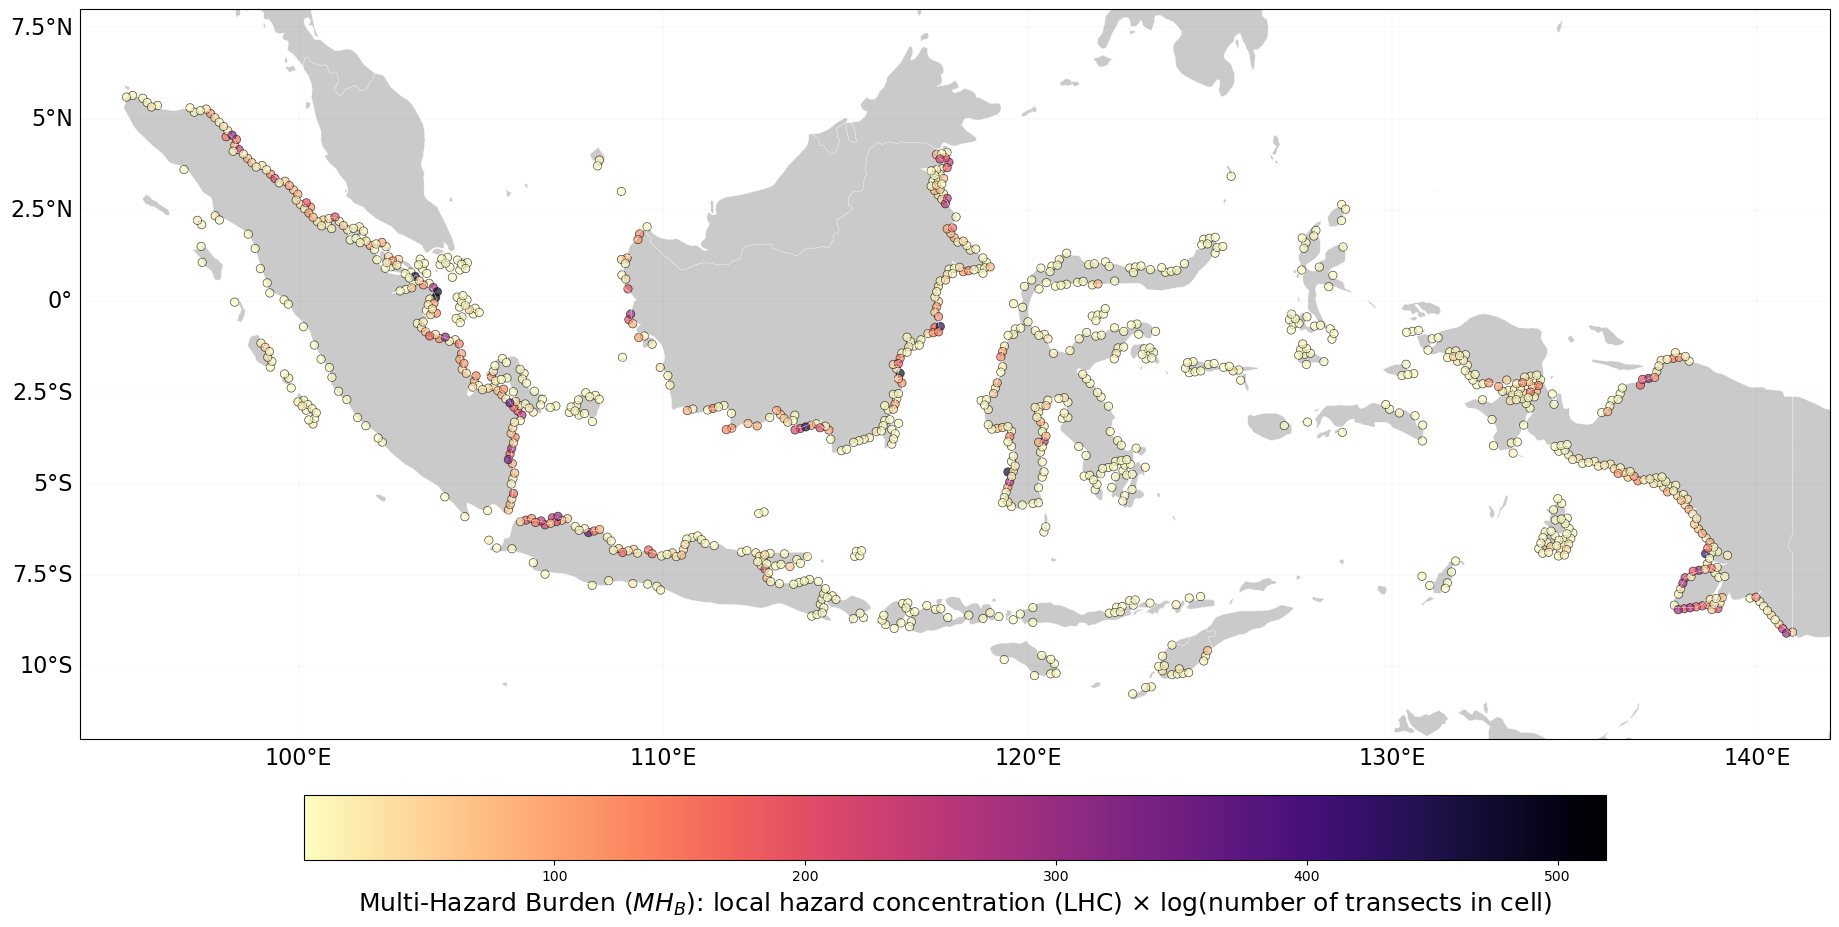

In [ ]:

fig, ax = initialize_map(figsize=(24,12))

key = 'MHB'

vmin = burden[key].quantile(0.01)
vmax = burden[key].quantile(0.99)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

burden.plot(
    column=key,
    cmap=plt.cm.magma_r,
    ax=ax,
    legend=True,
    edgecolor="black",
    alpha=0.7,
    linewidth=0.5,
        legend_kwds={
        # "label": "Conditional flood amplification ratio",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.06
    }
)

cbar_ax = fig.axes[-1]
cbar_ax.set_xlabel(
    r"Multi-Hazard Burden ($MH_B$): local hazard concentration (LHC) × log(number of transects in cell)",
    fontsize=18
)

xmin, ymin, xmax, ymax = 94, -12, 142, 8

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# plt.savefig(FIGURE_DIR / 'app_mhb_ina.png',
#                             dpi=300,
#                 bbox_inches="tight",
#                 pad_inches=0.05
#             )

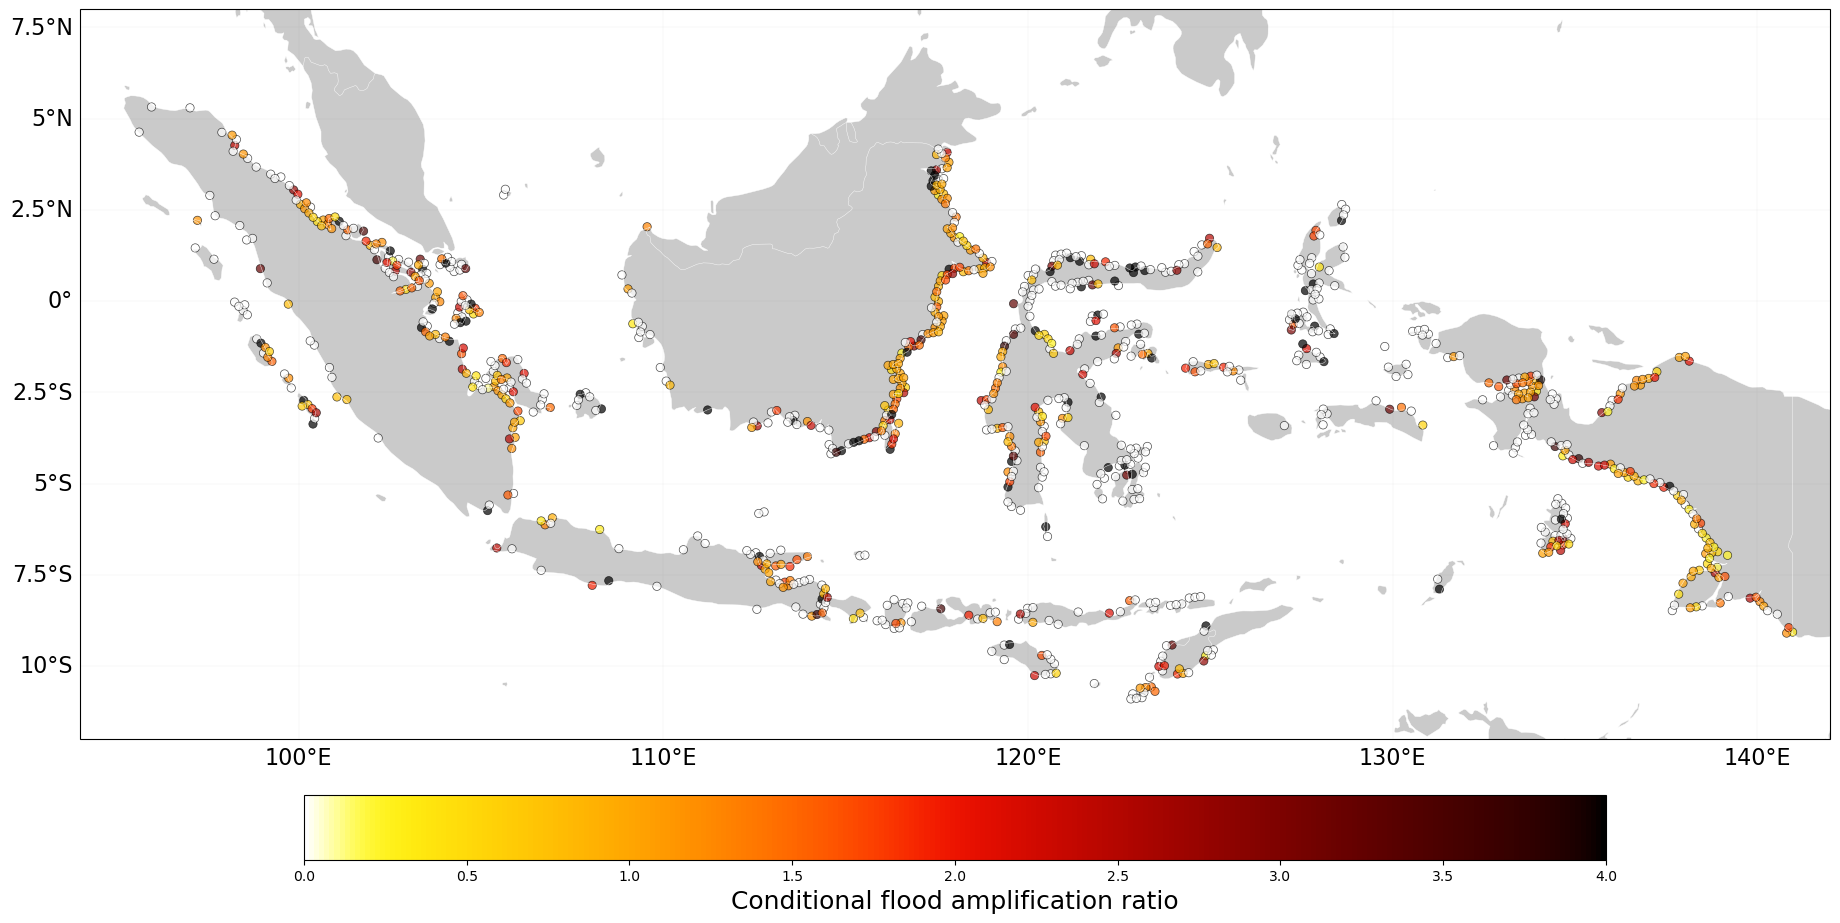

In [ ]:

fig, ax = initialize_map(figsize=(24,12))

key = 'amp_FES'

# vmin = amplification[key].quantile(0.01)
# vmax = amplification[key].quantile(0.99)

norm = mcolors.Normalize(vmin=0, vmax=4)

amplification.plot(
    column=key,
    cmap=cc.m_fire_r,
    ax=ax,
    norm = norm,
    legend=True,
    edgecolor="black",
    alpha=0.7,
    linewidth=0.5,
        legend_kwds={
        # "label": "Conditional flood amplification ratio",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.06
    }
)

cbar_ax = fig.axes[-1]
cbar_ax.set_xlabel(
    "Conditional flood amplification ratio",
    fontsize=18
)


xmin, ymin, xmax, ymax = 94, -12, 142, 8

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# plt.savefig(FIGURE_DIR / 'app_amp_ina.png',
#                             dpi=300,
#                 bbox_inches="tight",
#                 pad_inches=0.05
#             )

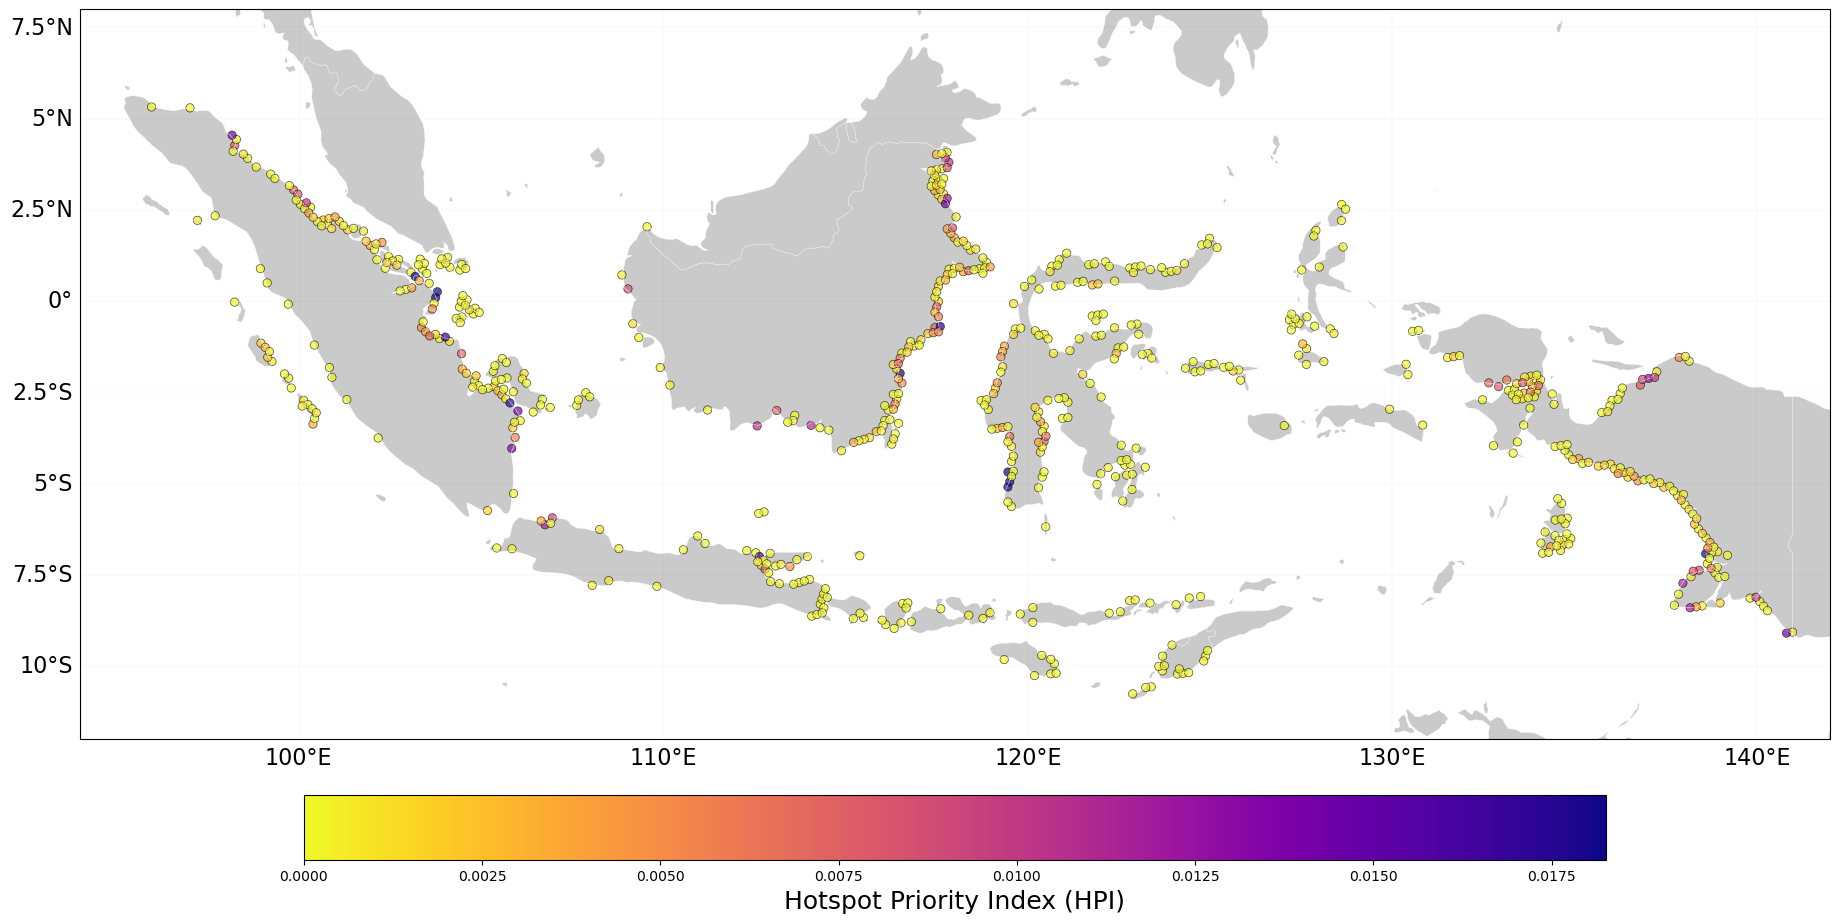

In [ ]:

fig, ax = initialize_map(figsize=(24,12))

key = 'HPI'

vmin = hpi[key].quantile(0.01)
vmax = hpi[key].quantile(0.99)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

hpi.plot(
    column=key,
    cmap=plt.cm.plasma_r,
    ax=ax,
    norm=norm,
    legend=True,
    edgecolor="black",
    alpha=0.7,
    linewidth=0.5,
        legend_kwds={
        # "label": "Conditional flood amplification ratio",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.06
    }
)

cbar_ax = fig.axes[-1]
cbar_ax.set_xlabel(
    r"Hotspot Priority Index (HPI)",
    fontsize=18
)

xmin, ymin, xmax, ymax = 94, -12, 142, 8

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# plt.savefig(FIGURE_DIR / 'app_hpi_ina.png',
#                 dpi=300,
#                 bbox_inches="tight",
#                 pad_inches=0.05
#             )